# Protein pathogenicity analysis workflow

This jupyter notebook is for **pathogenicity analysis of missense mutations in different protein regions**. It was used to analyze GLUT protein family responsible for glucose/fructose. Regions of focus are extracllular, intracellular and transmembrane domains, lining residues of tunnels, binding pockets and parts of lining residues that do not belong to binding pockets.

In [1]:
import source.helpers
import biolib
from pathlib import Path
import pandas as pd

from source import analysis, data, predict, regions
from source import path_method as pm

C:\Users\domin\anaconda3\envs\GLUT\Lib\site-packages\requests\__init__.py:86: RequestsDependencyWarning: Unable to find acceptable character detection dependency (chardet or charset_normalizer).
  warnings.warn(


In [2]:
# some libraries that might be neeeded
#pip install pymissense
#pip3 install --upgrade pybiolib 
#pip install gunicorn

Analyzed proteins. You can choose order of analysis to go in GLUT type groups by toggling `grouped` variable. It will change output heatmap image.

In [3]:
grouped = True
if grouped:
    proteins = {
    'GLUT1':'P11166',
    'GLUT2':'P11168',
    'GLUT3':'P11169',
    'GLUT4':'P14672',
    'GLUT14':'Q8TDB8',#group 1
    'GLUT5':'P22732',
    'GLUT7':'Q6PXP3',
    'GLUT9':'Q9NRM0',
    'GLUT11':'Q9BYW1',#group2
    'GLUT6':'Q9UGQ3',
    'GLUT8':'Q9NY64',
    'GLUT10':'O95528',
    'GLUT12':'Q8TD20',
    'GLUT13':'Q96QE2' #group3
}
else:
    proteins = {
    'GLUT1':'P11166',
    'GLUT2':'P11168',
    'GLUT3':'P11169',
    'GLUT4':'P14672',
    'GLUT5':'P22732',
    'GLUT6':'Q9UGQ3',
    'GLUT7':'Q6PXP3',
    'GLUT8':'Q9NY64',
    'GLUT9':'Q9NRM0',
    'GLUT10':'O95528',
    'GLUT11':'Q9BYW1',
    'GLUT12':'Q8TD20',
    'GLUT13':'Q96QE2',
    'GLUT14':'Q8TDB8' 
    }

## Get the data

download needed PDB and FASTA files

In [4]:
RES_DIR = Path.cwd() / 'results'
DATA_DIR = Path.cwd() / 'data'

#if results and data direcotries not exists create them
Path.mkdir(RES_DIR, exist_ok=True)
Path.mkdir(DATA_DIR, exist_ok=True)

In [5]:
#import pdb and fasta files
PDB_DIR = DATA_DIR / 'pdb'
FAS_DIR = DATA_DIR / 'fasta'

Path.mkdir(PDB_DIR, exist_ok=True)
Path.mkdir(FAS_DIR, exist_ok=True)
for up_id in proteins.values():
    
    data.get_pdb(up_id, PDB_DIR / f'{up_id}.pdb')
    data.get_fasta(up_id,FAS_DIR / f'{up_id}.fasta')

## Get predictions for proteins

**Pymissense** tool is used to predict pathogenicities for whole proteins. Predictions for **SIFT and PolyPhen-2 (Rhapsody) must be obtained manually**.

Expected directory for SIFT: `data/sift/`

Expected directory for PolyPhen-2: `data/rhapsody/`

**TIP**: if you have local copy of AlphaMissense TSV file use this. The file is 1.2 GB in ziped form and might take long time to download and extract.

In [6]:
alpha_missense_tsv = DATA_DIR / 'AlphaMissense_aa_substitutions.tsv'
data.get_alphamissense(alpha_missense_tsv)

AlphaMissense data already exists


In [7]:
# run pymissense for all proteins and generate csv of aminoacid pathogenicities

PYM_DIR = RES_DIR / 'pymissense'
Path.mkdir(PYM_DIR, exist_ok=True)

for up_id in proteins.values():
    pdb_file = PDB_DIR / f'{up_id}.pdb'
    
    print(f'running PyMissense for {up_id}')
    predict.pymissense(alpha_missense_tsv, pdb_file, up_id, PYM_DIR)

running PyMissense for P11166
AlphaMissense prediction for P11166 already exists
running PyMissense for P11168
AlphaMissense prediction for P11168 already exists
running PyMissense for P11169
AlphaMissense prediction for P11169 already exists
running PyMissense for P14672
AlphaMissense prediction for P14672 already exists
running PyMissense for Q8TDB8
AlphaMissense prediction for Q8TDB8 already exists
running PyMissense for P22732
AlphaMissense prediction for P22732 already exists
running PyMissense for Q6PXP3
AlphaMissense prediction for Q6PXP3 already exists
running PyMissense for Q9NRM0
AlphaMissense prediction for Q9NRM0 already exists
running PyMissense for Q9BYW1
AlphaMissense prediction for Q9BYW1 already exists
running PyMissense for Q9UGQ3
AlphaMissense prediction for Q9UGQ3 already exists
running PyMissense for Q9NY64
AlphaMissense prediction for Q9NY64 already exists
running PyMissense for O95528
AlphaMissense prediction for O95528 already exists
running PyMissense for Q8TD2

## Get protein regions

From PDB files we extract informations on positions of aminoacids and save it as csv with two columns for position (`residue_label`) and aminoacid type (`residue name`). Resulting files are saved to `results/regions/` directory.

In [8]:
#define dictionary of regions and their prefixes for file naming
reg_prefix = {'all':'all',
            'extracellular':'O',
            'membrane':'M',
            'intracellular':'I',
            'lining residues':'lr',
            'binding pocket':'bp',
            'lining residues outside pocket':'nobp_lr'}

### Whole proteins

In [9]:
REG_DIR = RES_DIR / 'regions'
Path.mkdir(REG_DIR, exist_ok=True)

In [10]:
for up_id in proteins.values():
    regions.all_residues(pdb_file = DATA_DIR / f'pdb/{up_id}.pdb', out_file = REG_DIR/ f'{reg_prefix['all']}_{up_id}.csv')

### Intracellular, extracellular and membrane regions

These regions are assigned to aminoacids automatically using **[DeepTMHMM](https://dtu.biolib.com/DeepTMHMM)** prediction method.

In [11]:
#get annotations of AA positions relative to the membrane using 
DTM_DIR = RES_DIR / 'deeptmhmm'
Path.mkdir(DTM_DIR, exist_ok=True)

deeptmhmm = biolib.load('DTU/DeepTMHMM')
for up_id in proteins.values():
    predict.deepTMHMM(deeptmhmm, FAS_DIR / f'{up_id}.fasta', up_id, DTM_DIR)

2026-03-04 16:05:17,387 | INFO : Loaded project DTU/DeepTMHMM:1.0.57
DeepTMHMM prediction for P11166 already exists
DeepTMHMM prediction for P11168 already exists
DeepTMHMM prediction for P11169 already exists
DeepTMHMM prediction for P14672 already exists
DeepTMHMM prediction for Q8TDB8 already exists
DeepTMHMM prediction for P22732 already exists
DeepTMHMM prediction for Q6PXP3 already exists
DeepTMHMM prediction for Q9NRM0 already exists
DeepTMHMM prediction for Q9BYW1 already exists
DeepTMHMM prediction for Q9UGQ3 already exists
DeepTMHMM prediction for Q9NY64 already exists
DeepTMHMM prediction for O95528 already exists
DeepTMHMM prediction for Q8TD20 already exists
DeepTMHMM prediction for Q96QE2 already exists


In [12]:
#processing of depptmhmm results
intracel = reg_prefix['intracellular']
extracel = reg_prefix['extracellular']
memb = reg_prefix['membrane']
for up_id in proteins.values():
    regions.membrane_residues(DTM_DIR / f'{up_id}.3line', REG_DIR, up_id, extracel, intracel, memb)

### Binding pockets

Predictions for following regions needed to be run manually using webservices. Binding pockets have been identified using **[PrankWeb](https://prankweb.cz/)**. Workflow uses CSV files that are part of PrankWeb output.

Expected directory for PrankWeb files is `data/prankweb/`

In [13]:
#this step is hard to automatize
#uses csv file from PrankWeb
for up_id in proteins.values():
    regions.binding_pockets(prankweb_csv = DATA_DIR / f'prankweb/{up_id}.csv', out_file = REG_DIR/ f'{reg_prefix['binding pocket']}_{up_id}.csv')

### Lining residues
Lining residues have been identified using **[MOLEonline](https://mole.upol.cz/)**. Workflow uses JSON files which are part of MOLEonline output.

Expected directory for MOLEonline files is `data/moleonline`

**WARNING:** Mole online can return varying results on same structures.

MOLEonline defaultly returns output ziped. For easier work we provide JSON extraction function.

In [14]:
##unziper for MOLEonline
#for glut in proteins.keys():
#    file_path = DATA_DIR / f'moleonline/{glut}.zip'
#    output = DATA_DIR / f'moleonline/{proteins[glut]}.json'
#    source.helpers.mole_zip2json(file_path, output)

In [15]:

for up_id in proteins.values():
    regions.lining_residues(moleonline_json = DATA_DIR / f'moleonline/{up_id}.json', out_file = REG_DIR/ f'{reg_prefix['lining residues']}_{up_id}.csv')

### Nonpocket binding residues

These residues are identified using outputs of two previous methods.

In [16]:
#nonbinding pocket lining residues
for up_id in proteins.values():
    regions.nonbinding_pocket_lining_residues(bp_residues_csv = REG_DIR / f'{reg_prefix['binding pocket']}_{up_id}.csv', l_residues_csv = REG_DIR / f'{reg_prefix['lining residues']}_{up_id}.csv', out_file = REG_DIR / f'{reg_prefix['lining residues outside pocket']}_{up_id}.csv')

## Assign pathogenicites

Using AlphaMissense/PolyPhen-2/SIFT predictions and region files we generate new csv files equivalent to region files with added `pathogenicity` column. These are saved to `results/pathogenicity/{method dir}` directories.

In [17]:
PAT_DIR = RES_DIR / 'pathogenicities'
AM_DIR = PAT_DIR / 'alphamissense'
PP_DIR = PAT_DIR / 'rhapsody'
SI_DIR = PAT_DIR / 'sift'

Path.mkdir(PAT_DIR, exist_ok=True)
Path.mkdir(AM_DIR, exist_ok=True)
Path.mkdir(PP_DIR, exist_ok=True)
Path.mkdir(SI_DIR, exist_ok=True)

First we generate files for complete proteins.

In [18]:

for glut in proteins.keys():
    pm.alphamissense_residues(RES_DIR / f'pymissense/{proteins[glut]}-edit.pdb', AM_DIR / f'{reg_prefix['all']}_{proteins[glut]}.csv')
    pm.polyphen2_residues(DATA_DIR / f'rhapsody/{glut}.txt', PP_DIR / f'{reg_prefix['all']}_{proteins[glut]}.csv')
    pm.sift_residues(DATA_DIR / f'sift/SIFT_{glut}.txt', SI_DIR / f'{reg_prefix['all']}_{proteins[glut]}.csv')   

Pathogenicity files for complete proteins are then used to assign pathogenicity to other regions.

In [19]:
for up_id in proteins.values():
    am_patho_csv = AM_DIR / f'{reg_prefix['all']}_{up_id}.csv'
    pp_patho_csv = PP_DIR / f'{reg_prefix['all']}_{up_id}.csv'
    si_patho_csv = SI_DIR / f'{reg_prefix['all']}_{up_id}.csv'

    #create file for rest of regions
    for reg in list(reg_prefix.keys())[1:]:
        analysis.assign_pathogenicity(am_patho_csv, region_csv = REG_DIR / f'{reg_prefix[reg]}_{up_id}.csv',out_file = AM_DIR / f'{reg_prefix[reg]}_{up_id}.csv')
        analysis.assign_pathogenicity(pp_patho_csv, region_csv = REG_DIR / f'{reg_prefix[reg]}_{up_id}.csv',out_file = PP_DIR / f'{reg_prefix[reg]}_{up_id}.csv')
        analysis.assign_pathogenicity(si_patho_csv, region_csv = REG_DIR / f'{reg_prefix[reg]}_{up_id}.csv',out_file = SI_DIR / f'{reg_prefix[reg]}_{up_id}.csv')

## Average pathogenicities

In the next step we generate csv files of average pathogenicities for each region of each analyzed protein. Results are csv files with `identifier` and `average_pathogenicity` columns. 

In [20]:
for prefix in reg_prefix.values():
    analysis.average_pathogenicity(patho_dir = AM_DIR, region_prefix = prefix, up_id_list = proteins.values(), out_file = AM_DIR / f'{prefix}_average_patho.csv')
    analysis.average_pathogenicity(patho_dir = PP_DIR, region_prefix = prefix, up_id_list = proteins.values(), out_file = PP_DIR / f'{prefix}_average_patho.csv')
    analysis.average_pathogenicity(patho_dir = SI_DIR, region_prefix = prefix, up_id_list = proteins.values(), out_file = SI_DIR / f'{prefix}_average_patho.csv')


## United pathogenicites
Average pathogenicities are then used to generate csvs containing average pathogenicties of all regions.

In [21]:
for directory in [AM_DIR, PP_DIR, SI_DIR]:
    files = []
    for prefix in reg_prefix.values():
        files.append(directory / f'{prefix}_average_patho.csv')
    columns = ['identifier']+list(reg_prefix.keys())
    df = source.helpers.unite_csvs(files, directory / 'united_averages.csv', id_col = 1, colnames = columns, return_df = True)
df

,identifier,all,extracellular,membrane,intracellular,lining residues,binding pocket,lining residues outside pocket
0,P11166,0.114499,0.179801,0.079474,0.148377,0.055940,0.043398,0.062919
1,P11168,0.114389,0.200104,0.075405,0.125617,0.046469,0.030190,0.124211
2,P11169,0.107207,0.168725,0.074356,0.135077,0.043387,0.048862,0.057737
3,P14672,0.111174,0.173351,0.074309,0.147179,0.045172,0.034944,0.061684
4,Q8TDB8,0.106301,0.174294,0.077075,0.116512,0.047986,0.042197,0.068684
5,P22732,0.106218,0.145796,0.080312,0.131281,0.091805,0.059230,0.122632
6,Q6PXP3,0.113382,0.156032,0.083813,0.134110,0.070042,0.056100,0.074816
7,Q9NRM0,0.106898,0.172083,0.087784,0.109574,0.083509,0.074707,0.068947
8,Q9BYW1,0.118849,0.181244,0.096947,0.131586,0.104095,0.097350,0.122158
9,Q9UGQ3,0.116769,0.218465,0.088078,0.107612,0.066737,0.061504,0.055480


We switch to GLUT identifiers for easier reading of heatmaps.

In [22]:
#rename to GLUT names
for directory in [AM_DIR, PP_DIR, SI_DIR]:
    for glut_id in proteins.keys():
        united_df = pd.read_csv(directory / 'united_averages.csv')
        i = united_df[united_df['identifier']==proteins[glut_id]].index
        united_df.at[i.values[0], 'identifier'] = glut_id
        united_df.to_csv(directory / 'united_averages.csv', index=False)

## Produce pathogenicity heatmaps

Using united pathogenicity files we produce heatmaps for AlphaMissense, PolyPhen-2 and SIFT. Heat maps are saved as PNG images in `results` directory.

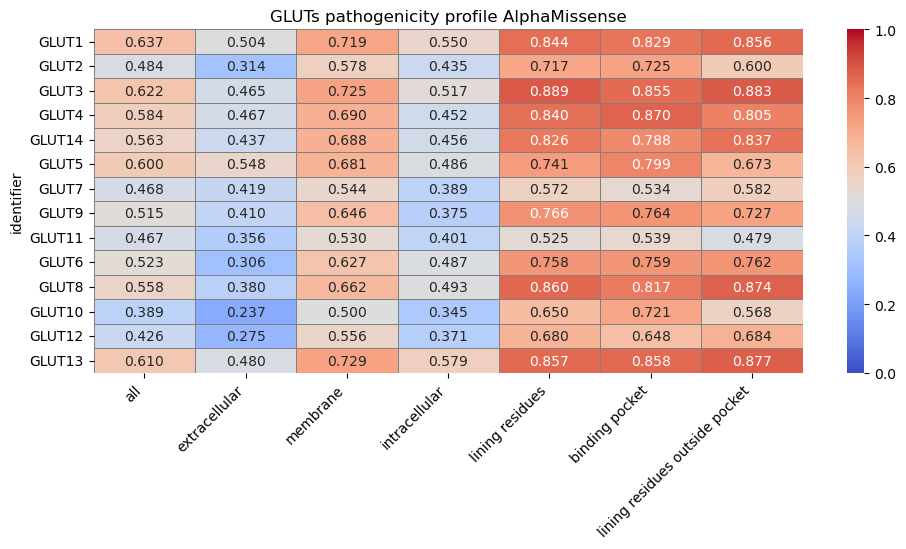

In [23]:
#create heatmaps
#alphamissense
analysis.crate_heatmap(AM_DIR / 'united_averages.csv', 'AlphaMissense', RES_DIR / 'AlphaMissense_pathogenicity_heatmap.png')

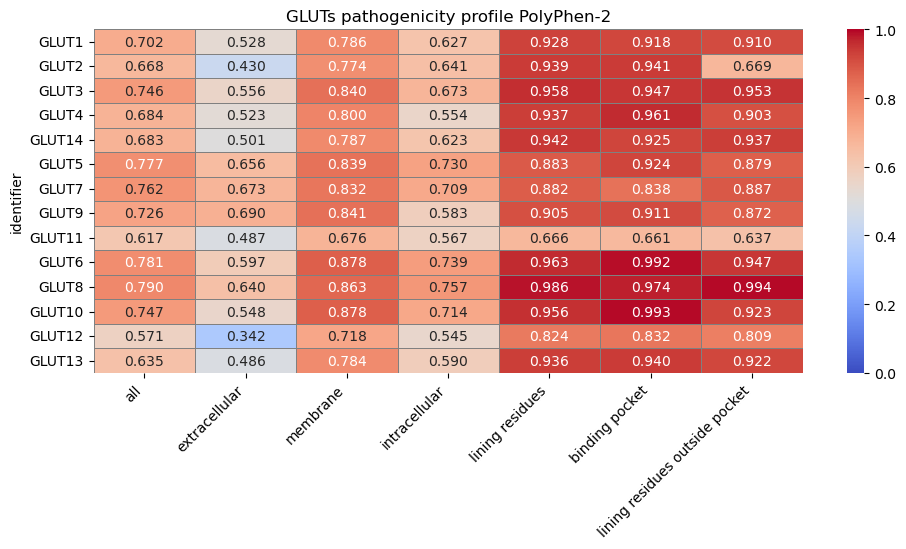

In [24]:
#create heatmaps
#polyphen-2
analysis.crate_heatmap(PP_DIR / 'united_averages.csv', 'PolyPhen-2', RES_DIR / 'PolyPhen-2_pathogenicity_heatmap.png')

**NOTE:** SIFT uses opposite approach to scoring pathogenicities to AlphaMissense and PolyPhen-2. SIFT score of 0 means highest pathogenicity with nimber growing meaning more benign result. Thus we use inverse coloring for SIFT heatmap.

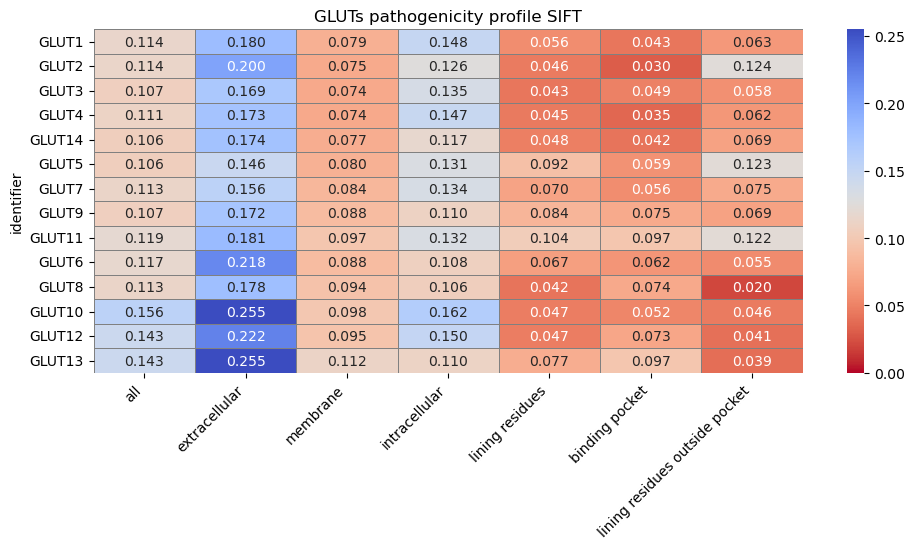

In [25]:
#create heatmaps
#sift
analysis.crate_heatmap(SI_DIR / 'united_averages.csv', 'SIFT', RES_DIR / 'SIFT_pathogenicity_heatmap.png', inverse_color = True)